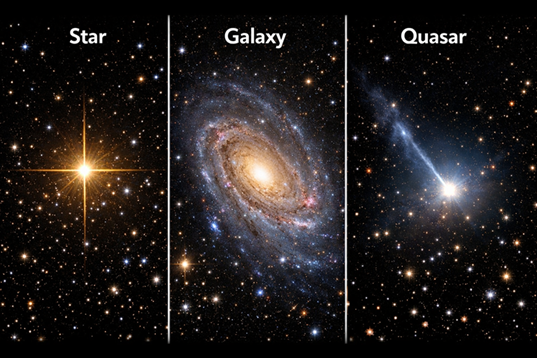

# Clasificación de Objetos Astronómicos con *Machine Learning* usando SDSS

**Autor (portafolio):** *Notebook académico — Sloan Digital Sky Survey (SDSS) DR17*  
**Dataset:** [Stellar Classification Dataset - SDSS17](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17) (Kaggle, fedesoriano)

---

## Estructura del proyecto (secciones)

1. **Introducción** — contexto del SDSS, relevancia científica, clasificación multiclase y referencias.
2. **Descripción del dataset** — diccionario de variables y variable objetivo.
3. **Carga de datos** — inspección inicial (`head`, `shape`, columnas).
4. **Análisis exploratorio (EDA)** — distribuciones, balance de clases, relaciones bivariadas y correlaciones.
5. **Selección de variables** — criterios para excluir columnas y conjunto de *features* para modelado.
6. **Preprocesamiento** — `ColumnTransformer`, escalado, `OneHotEncoder` (y por qué evitar `LabelEncoder` en *features*).
7. **División de datos** — `train_test_split` con `stratify`.
8. **Modelos** — Regresión logística, *Random Forest*, *Gradient Boosting*, MLP.
9. **Evaluación** — *accuracy*, precisión, recall, F1, matrices de confusión.
10. **Optimización** — `GridSearchCV`.
11. **Interpretabilidad** — importancia de variables.
12. **Discusión científica** — lectura astronómica de los resultados.
13. **Conclusiones** — mejor modelo, limitaciones y trabajo futuro.

---



## 1. Introducción

### 1.1 ¿Qué es el SDSS?

El **Sloan Digital Sky Survey (SDSS)** es un gran proyecto de astronomía que ha mapeado una parte importante del cielo en luz óptica. Observa muchos objetos celestes y registra datos como su posición, brillo en distintos filtros y, en algunos casos, información espectroscópica. Gracias a sus catálogos masivos, sirve para estudiar estrellas, galaxias, cuásares y fenómenos del Universo a gran escala.

En este notebook usamos un subconjunto representativo orientado a **clasificación**: cada fila corresponde a un objeto con mediciones y una etiqueta de clase asignada en el marco del survey.

### 1.2 Importancia científica

Clasificar objetos en **STAR / GALAXY / QSO** no es un ejercicio meramente técnico:

- **Eficiencia en la ciencia de datos astronómicos:** los surveys modernos generan billones de mediciones; automatizar (o asistir) la clasificación acelera la construcción de muestras limpias para análisis posteriores.
- **Calibración de pipelines:** comparar modelos estadísticos contra etiquetas de referencia ayuda a entender qué señales fotométricas y espectroscópicas separan mejor cada clase.
- **Puente entre fotometría y espectroscopía:** en muchos escenarios reales se dispone antes de fotometría “barata” y abundante, mientras que el espectro es más costoso. Un modelo puede aproximar reglas de decisión útiles siempre que seamos cuidadosos con **sesgos** y **fuga de información** (*data leakage*).

### 1.3 ¿Qué es la clasificación multiclase?

En **clasificación multiclase**, la variable objetivo toma **más de dos categorías** excluyentes. Aquí:

- **STAR:** objetos estelares (puntos-like en ciertas escalas, con comportamiento fotométrico típico de estrellas).
- **GALAXY:** objetos extendidos asociados a galaxias (morfo-fotometría y colores distintos).
- **QSO (cuásar):** núcleos activos de galaxias, usualmente muy lejanos y con firmas observables (por ejemplo, relacionadas con continuo y redshift en el contexto del survey).

Formalmente, buscamos una función aproximada \(f(\mathbf{x})\) que asigne a un vector de *features* \(\mathbf{x}\) una de las tres etiquetas. Los modelos que veremos más adelante producen:

- una **clase predicha** (por *argmax* sobre probabilidades o scores), y/o
- **probabilidades por clase** (cuando el estimador lo permite), útiles para umbrales y análisis de errores.

### 1.4 Objetivo de modelado (lo que haremos después)

Construiremos **pipelines** reproducibles (preprocesamiento + modelo) para aprender \(f\) desde datos tabulares, evaluaremos el desempeño con métricas adecuadas a multiclase y discutiremos qué tan “astronómicamente plausible” es lo que aprende el modelo —en particular, qué variables impulsan las decisiones.

### 1.5 Fuentes y referencias

**Referencias**

- York, D. G., *et al.* (2000). The Sloan Digital Sky Survey: Technical Summary. *The Astronomical Journal*, *120*(3), 1579–1587. https://doi.org/10.1086/301513
- *Sloan Digital Sky Survey*. (s. f.). *Data Release 17* y documentación asociada. Recuperado el 3 de abril de 2026 de https://www.sdss.org/dr17/
- Soriano, F. (*s. f.*). *Stellar Classification Dataset - SDSS17* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17
- Pedregosa, F., *et al.* (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html (documentación multiclase: https://scikit-learn.org/stable/modules/multiclass.html)
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2.ª ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7

## 2. Descripción del dataset


El archivo típico del repositorio de Kaggle contiene **una tabla** donde cada fila es un objeto y las columnas mezclan:

- **Identificadores** del survey (útiles para trazabilidad, no necesariamente para generalización).
- **Fotometría** en las bandas **u, g, r, i, z** (magnitudes; a menor magnitud, mayor brillo).
- **Posición** en el cielo (**alpha**, **delta**).
- **Redshift** espectroscópico (cuando está disponible / asociado al objeto).
- **Metadatos** de observación (placa, MJD, fibra, *run*, etc.).
- La columna **`class`**: etiqueta categórica objetivo.

### 2.1 Tabla de variables

| Columna | Tipo típico | Descripción breve | ¿Útil para modelar? |
|---|---|---|---|
| `obj_ID` | entero | Identificador del objeto en el catálogo. | **No** (ID; no generaliza). |
| `alpha` | float | Ascensión recta (coordenada angular). | **Opcional / cuestionable** (puede introducir sesgos espurios si el survey no es homogéneo). |
| `delta` | float | Declinación (coordenada angular). | Igual que `alpha`. |
| `u`, `g`, `r`, `i`, `z` | float | Magnitudes en bandas SDSS. | **Sí** (señal fotométrica central). |
| `run_ID` | entero | Identificador de “run” de observación. | **No** (metadato operativo). |
| `rerun_ID` | entero | Identificador de reprocesamiento. | **No** (casi constante en muchas muestras). |
| `cam_col` | entero | Columna de la CCD camera. | **No** (metadato instrumental). |
| `field_ID` | entero | Campo dentro del run. | **No** (metadato operativo). |
| `spec_obj_ID` | entero | ID del objeto espectroscópico. | **No** (ID). |
| `class` | texto | **Etiqueta:** `STAR`, `GALAXY`, `QSO`. | **Es la variable objetivo** \(y\). |
| `redshift` | float | Redshift (información relacionada con espectroscopía). | **Sí** (muy discriminativa; ver nota científica abajo). |
| `plate` | entero | Placa del espectrógrafo. | **No** (metadato de observación). |
| `MJD` | entero | Fecha juliana modificada de la observación. | **No** (metadato temporal). |
| `fiber_ID` | entero | Fibra espectroscópica. | **No** (metadato instrumental). |

### 2.2 Variable objetivo

- **Objetivo:** `class` con tres categorías: **STAR**, **GALAXY**, **QSO**.
- **Tipo de problema:** clasificación supervisada multiclase.

### 2.3 Nota científica importante sobre `redshift`

En este dataset, `redshift` y la etiqueta `class` provienen de un contexto **espectroscópico** del SDSS. Por ello, `redshift` suele ser **extremadamente predictivo** (no es “trampa” estadística en el sentido de error de registro, pero **sí cambia el enunciado científico**):

- Con `redshift`, el problema puede volverse “casi trivial” en términos de *accuracy*.
- Sin `redshift`, el problema se parece más a un escenario de **fotometría pura**, mucho más desafiante y relevante para ciertos casos de uso.

## 3. Carga de datos


### 3.1 Compatibilidad: entorno local vs Google Colab

- **Local / VS Code / Cursor:** si `star_classification.csv` está en la misma carpeta que el notebook, la ruta por defecto funciona.
- **Colab:** sube el CSV (o monta Drive / usa la API de Kaggle). Ajusta `DATA_PATH` en la siguiente celda.

In [45]:
from pathlib import Path
import pandas as pd
import numpy as np

# Carpeta actual desde donde se está ejecutando el script o notebook
BASE_DIR = Path.cwd()
print("Directorio de trabajo actual:", BASE_DIR)

# Ruta principal: mismo directorio donde estás trabajando en VSCode
DATA_PATH = BASE_DIR / "star_classification.csv"

# Alternativas comunes
possible_paths = [
    DATA_PATH,
    BASE_DIR / "data" / "star_classification.csv",
    Path("/content/star_classification.csv"),  # por si también lo abres en Colab
]

# Buscar el archivo en las rutas posibles
for path in possible_paths:
    if path.is_file():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError(
        "No se encontró 'star_classification.csv'.\n"
        f"Directorio actual: {BASE_DIR}\n"
        f"Rutas buscadas:\n" + "\n".join(str(p) for p in possible_paths)
    )

print("Archivo encontrado en:", DATA_PATH)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Leer CSV
df = pd.read_csv(DATA_PATH)
df.head()


Directorio de trabajo actual: g:\Mi unidad\Programming\VSCode\Git\MLOps_UdeM_Intro
Archivo encontrado en: g:\Mi unidad\Programming\VSCode\Git\MLOps_UdeM_Intro\star_classification.csv


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


### 3.2 ¿Qué inspeccionamos y por qué?

- **`head()`:** validar nombres de columnas, escalas numéricas y formato de `class`.
- **`shape`:** tamaño muestral (afecta varianza de métricas y coste computacional).
- **`info()` / tipos:** detectar `object` vs numéricos y posibles problemas de parseo.
- **Valores faltantes:** decidir imputación o descarte en preprocesamiento.


In [46]:
print("shape (filas, columnas):", df.shape)
print("columnas:", list(df.columns))
print()
df.info()


shape (filas, columnas): (100000, 18)
columnas: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null

In [47]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,NaN,NaN,NaN,1237664721814903296.0,8438559894562.569336,1237645942904389888.0,1237659161195119360.0,1237663463144292864.0,1237668350286447104.0,1237680531356386304.0
alpha,100000.0,NaN,NaN,NaN,177.629117,96.502241,0.005528,127.518222,180.9007,233.895005,359.99981
delta,100000.0,NaN,NaN,NaN,24.135305,19.644665,-18.785328,5.146771,23.645922,39.90155,83.000519
u,100000.0,NaN,NaN,NaN,21.980468,31.769291,-9999.0,20.352353,22.179135,23.68744,32.78139
g,100000.0,NaN,NaN,NaN,20.531387,31.750292,-9999.0,18.96523,21.099835,22.123767,31.60224
r,100000.0,NaN,NaN,NaN,19.645762,1.85476,9.82207,18.135828,20.12529,21.044785,29.57186
i,100000.0,NaN,NaN,NaN,19.084854,1.757895,9.469903,17.732285,19.405145,20.396495,32.14147
z,100000.0,NaN,NaN,NaN,18.66881,31.728152,-9999.0,17.460677,19.004595,19.92112,29.38374
run_ID,100000.0,NaN,NaN,NaN,4481.36606,1964.764593,109.0,3187.0,4188.0,5326.0,8162.0
rerun_ID,100000.0,NaN,NaN,NaN,301.0,0.0,301.0,301.0,301.0,301.0,301.0


In [48]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: int64)

## 4. Análisis exploratorio de datos (EDA)


### 4.1 Idea general del EDA

El EDA sirve para:

1. **Entender la distribución** de cada variable (colas pesadas, outliers, rangos).
2. **Revisar el balance** de clases (si hay desbalance fuerte, *accuracy* puede ser engañosa).
3. **Explorar relaciones** entre variables (scatter / densidad) que sugieran separabilidad entre STAR/GALAXY/QSO.
4. **Detectar correlaciones fuertes** entre *features* (multicolinealidad; implicaciones para modelos lineales vs árboles).

Usaremos estilo visual consistente y fijamos semilla para cualquier muestreo aleatorio en plots si aplica.


### Dependencias para el EDA

**Google Colab** trae instalados `pandas`, `matplotlib` y `seaborn`. En un entorno local mínimo a veces falta `seaborn`; la siguiente celda lo instala solo si hace falta (no modifica Colab de forma relevante si ya está presente).


In [49]:
import sys
import subprocess


def _ensure_seaborn() -> None:
    try:
        import seaborn  # noqa: F401
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

_ensure_seaborn()


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

PHOT_COLS = ["u", "g", "r", "i", "z"]

### 4.2 Distribución de la variable objetivo (`class`)

**Qué miramos:** conteos absolutos y relativos por clase.  
**Por qué importa:** si una clase domina, un modelo “tonto” que siempre predice la mayoritaria puede obtener *accuracy* aparentemente alta.  
**Cómo interpretarlo:** contrastar *accuracy* con macro/micro F1 en la fase de evaluación.


In [51]:
class_counts = df["class"].value_counts().sort_values(ascending=False)
class_pct = (class_counts / len(df) * 100).round(2)

summary = pd.DataFrame({"count": class_counts, "pct": class_pct})
summary

,count,pct
class,,
GALAXY,59445,59.44
STAR,21594,21.59
QSO,18961,18.96


C:\Users\ElCientifico\AppData\Local\Temp\ipykernel_29768\901782365.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary["count"], palette="viridis", ax=ax[0])


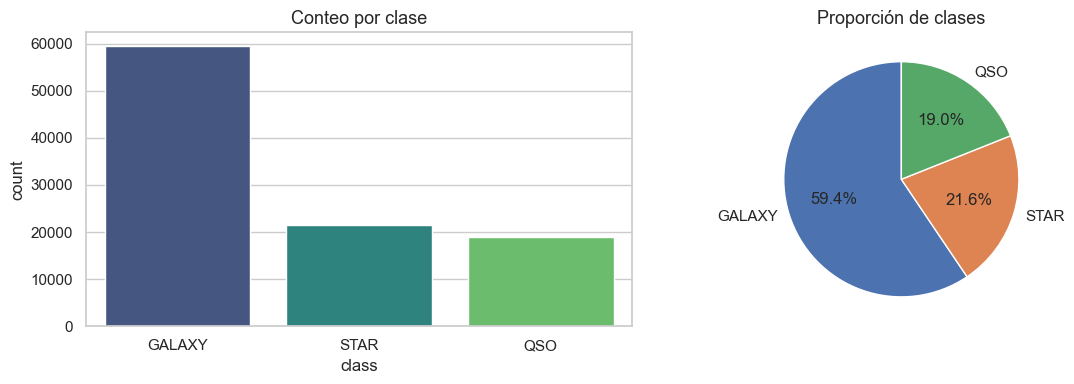

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=summary.index, y=summary["count"], palette="viridis", ax=ax[0])
ax[0].set_title("Conteo por clase")
ax[0].set_xlabel("class")
ax[0].set_ylabel("count")

ax[1].pie(summary["count"], labels=summary.index, autopct="%1.1f%%", startangle=90)
ax[1].set_title("Proporción de clases")

plt.tight_layout()
plt.show()

**Interpretación (guía):** si las tres barras son del mismo orden de magnitud, el dataset está razonablemente equilibrado; si una clase es muy pequeña, conviene reportar métricas por clase y considerar `class_weight` o remuestreo en modelación.


### 4.3 Histogramas de magnitudes y redshift

**Qué miramos:** forma de la distribución (asimetría), presencia de colas y outliers.  
**Por qué:** las magnitudes definen el espacio de color; muchos algoritmos se benefician de escalado si usamos distancias o regularización.  
**Interpretación:** curvas muy similares entre clases en una banda sugieren menor poder discriminativo marginal; separación visible sugiere señal útil (confirmaremos con modelos multivariantes).


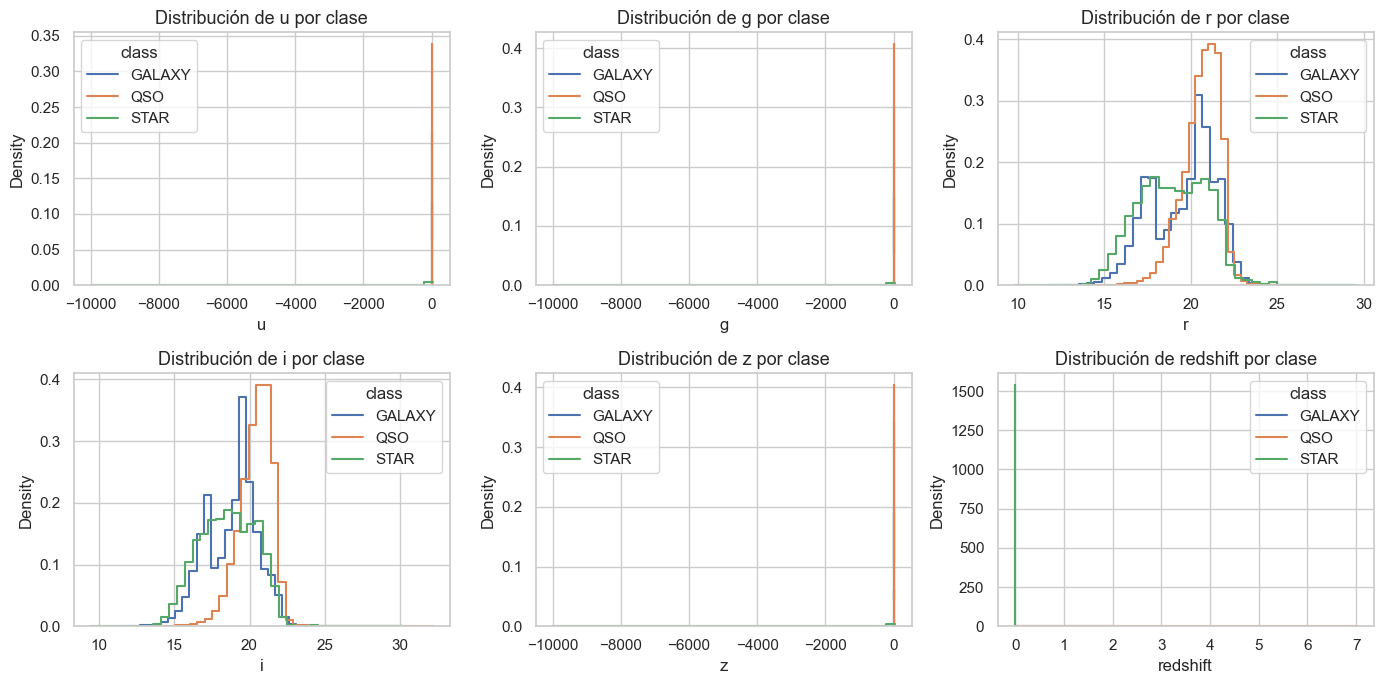

In [53]:
plot_cols = PHOT_COLS + ["redshift"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    for c in sorted(df["class"].unique()):
        sns.histplot(df.loc[df["class"] == c, col], bins=40, stat="density", element="step", fill=False, ax=ax, label=c)
    ax.set_title(f"Distribución de {col} por clase")
    ax.set_xlabel(col)
    ax.legend(title="class")

plt.tight_layout()
plt.show()


### 4.4 Scatter plots (ejemplos de espacio de color)

**Qué miramos:** si hay nubes separables en proyecciones 2D del espacio fotométrico.  
**Por qué:** la separación multiclase raramente se ve en una sola variable, pero pares como **(g−r) vs (r−i)** suelen ser informativos en astronomía.  
**Interpretación:** solapamiento no implica que el modelo falle (puede haber separación en más dimensiones), pero anticipa errores sistemáticos entre clases parecidas fotométricamente.


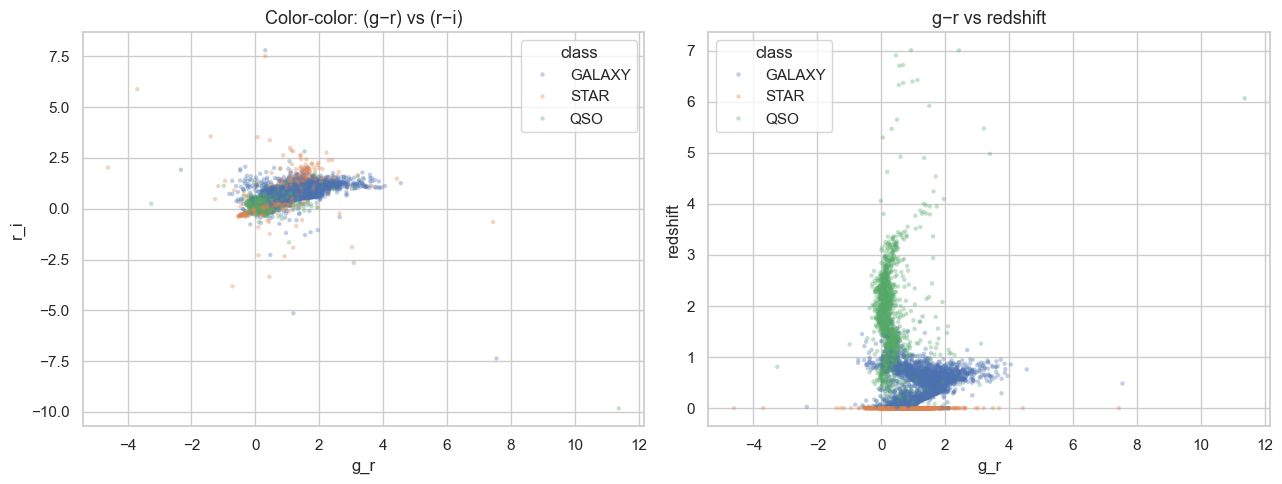

In [54]:
# Submuestreo para visualización (el dataset completo puede ser pesado para scatter)
sample_n = min(8000, len(df))
df_vis = df.sample(n=sample_n, random_state=RANDOM_STATE)

df_vis["g_r"] = df_vis["g"] - df_vis["r"]
df_vis["r_i"] = df_vis["r"] - df_vis["i"]
df_vis["u_g"] = df_vis["u"] - df_vis["g"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df_vis, x="g_r", y="r_i", hue="class", alpha=0.35, s=10, linewidth=0, ax=ax[0])
ax[0].set_title("Color-color: (g−r) vs (r−i)")

sns.scatterplot(data=df_vis, x="g_r", y="redshift", hue="class", alpha=0.35, s=10, linewidth=0, ax=ax[1])
ax[1].set_title("g−r vs redshift")

plt.tight_layout()
plt.show()


**Interpretación (típica en este tipo de catálogos):**  
- **QSO** a menudo aparecen en regiones de color/redshift distintas respecto a muchas **STAR** cercanas.  
- **GALAXY** puede solaparse con estrellas en algunas proyecciones, lo que exige modelos multivariantes o más *features*.


### 4.5 Correlación entre variables numéricas

**Qué miramos:** matriz de correlación (Pearson) entre variables numéricas relevantes.  
**Por qué:** correlaciones muy altas entre magnitudes son esperables (objetos más brillantes tienden a ser más brillantes en todas las bandas), lo que afecta interpretación de coeficientes en modelos lineales.  
**Interpretación:** heatmap con bloques fuertes sugiere redundancia; los modelos basados en árboles suelen tolerar mejor redundancia que regresión logística sin regularización adecuada.


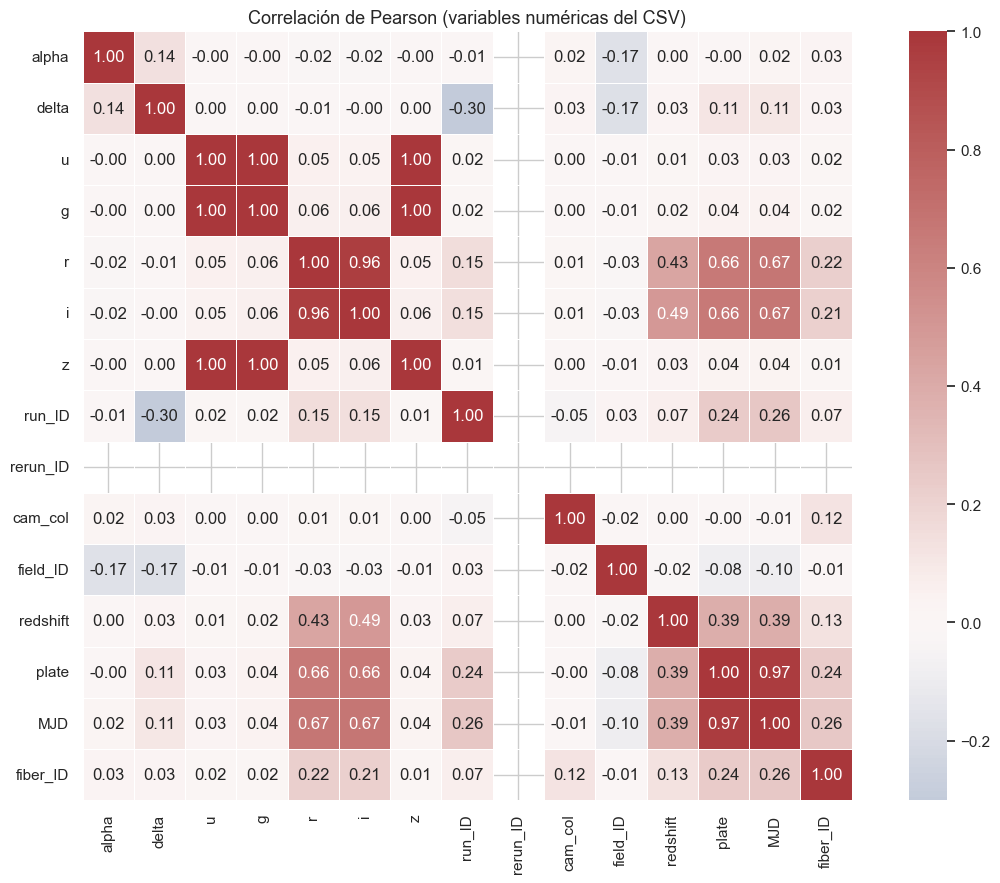

In [55]:
# Excluimos IDs enteros enormes: su correlación de Pearson no es astrofísicamente interpretable aquí.
exclude_corr = {"class", "obj_ID", "spec_obj_ID"}
corr_cols = [c for c in df.columns if c not in exclude_corr]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    square=True,
    annot=True,      # Muestra los valores
    fmt=".2f",       # Formato con 2 decimales
    linewidths=0.5
)
plt.title("Correlación de Pearson (variables numéricas del CSV)")
plt.tight_layout()
plt.show()


### 4.6 Síntesis del EDA (para el lector del portafolio)

1. **Calidad:** confirmamos tipos, rango de magnitudes y ausencia/presencia de faltantes.
2. **Balance:** comparamos proporciones STAR/GALAXY/QSO para contextualizar métricas globales.
3. **Señal:** histogramas y scatter sugieren qué variables podrían separar clases (especialmente en combinación).
4. **Multicolinealidad:** la correlación entre magnitudes y metadatos numéricos informa decisiones de modelado e interpretación.

Este EDA **no reemplaza** el diagnóstico final: la evaluación honesta en *hold-out* (sección 7–9) manda sobre impresiones visuales.


## 5. Selección de variables (*feature selection* conceptual)


### 5.1 Principios

Queremos entrenar modelos que **generalicen** a nuevas observaciones, no que memoricen artefactos del survey. Por eso separamos:

- **Señal física / instrumental útil:** fotometría (u–z) y, si lo permitimos explícitamente, `redshift`.
- **Identificadores y metadatos operativos:** útiles para auditoría, pero peligrosos como *features* porque pueden correlacionar con clase por **estructura del muestreo** (por ejemplo, ciertos *runs* o placas asociados a programas de observación), no por física del objeto.

### 5.2 Columnas que eliminaremos antes del modelado (y justificación)

| Columna | Motivo típico |
|---|---|
| `obj_ID`, `spec_obj_ID` | Identificadores únicos: no aportan generalización; riesgo de memorización si se tratara como categoría. |
| `run_ID`, `rerun_ID`, `cam_col`, `field_ID` | Metadatos de observación/procesamiento: pueden capturar **sesgos de muestreo** más que propiedades astrofísicas del objeto. |
| `plate`, `MJD`, `fiber_ID` | Metadatos espectroscópicos/operativos: similar al punto anterior. |
| `alpha`, `delta` | Coordenadas celestes: pueden ser relevantes en algunos estudios (variación galáctica), pero en portafolio suelen **introducir señales espurias** si no se modela cuidadosamente la geometría del survey; aquí las excluimos para centrarnos en fotometría (+ redshift). |

### 5.3 Conjunto de *features* retenidas

Por defecto:

- **X:** `u`, `g`, `r`, `i`, `z`, `redshift`
- **y:** `class`

En la siguiente celda verificamos cardinalidades (por ejemplo, si `rerun_ID` es constante) como refuerzo empírico de la decisión.


In [56]:
ID_AND_SURVEY_COLS = [
    "obj_ID",
    "spec_obj_ID",
    "run_ID",
    "rerun_ID",
    "cam_col",
    "field_ID",
    "plate",
    "MJD",
    "fiber_ID",
    "alpha",
    "delta",
]

FEATURE_COLS = ["u", "g", "r", "i", "z", "redshift"]
TARGET_COL = "class"

nunique_check = df[ID_AND_SURVEY_COLS].nunique().sort_values()
nunique_check.to_frame("nunique")


,nunique
rerun_ID,1
cam_col,6
run_ID,430
field_ID,856
fiber_ID,1000
MJD,2180
plate,6284
obj_ID,78053
delta,99999
alpha,99999


In [57]:
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print("Features retenidas:", FEATURE_COLS)
print("Target:", TARGET_COL)
print("Shape X:", X.shape)
print("Shape y:", y.shape)

X.head()


Features retenidas: ['u', 'g', 'r', 'i', 'z', 'redshift']
Target: class
Shape X: (100000, 6)
Shape y: (100000,)


,u,g,r,i,z,redshift
0,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794
1,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136
2,25.26307,22.66389,20.60976,19.34857,18.94827,0.644195
3,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346
4,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123


**Interpretación:** a partir de aquí, el flujo de MLOps debe tratar `X` e `y` como la interfaz hacia *pipelines* de preprocesamiento y modelos (sección 6 en adelante). Si decides un experimento **sin** `redshift`, basta con removerla de `FEATURE_COLS` y documentar el cambio en la discusión científica.


---
## 6. Preprocesamiento

### 6.1 ¿Qué hacemos y por qué?

Antes de entrenar, las *features* deben transformarse de forma **reproducible** y **sin fuga de información** del conjunto de prueba hacia el de entrenamiento. Por eso encapsulamos todo en un **`Pipeline`**: el preprocesamiento aprende estadísticas (por ejemplo, media y desviación típica del escalado) **solo con `fit` en train**.

### 6.2 `ColumnTransformer` y escalado

Tras la sección 5, **`X` es enteramente numérica** (`u, g, r, i, z, redshift`). Usamos:

- **`StandardScaler`**: centra y escala cada columna. Es especialmente útil para **regresión logística** y **MLP**, que son sensibles a la magnitud de las variables. Los modelos basados en árboles no lo requieren estrictamente, pero mantener el mismo preprocesamiento para todos los modelos **unifica el flujo MLOps** y facilita comparar pipelines.

### 6.3 `OneHotEncoder` (¿dónde va aquí?)

`OneHotEncoder` convierte variables **categóricas nominales** (sin orden natural) en columnas binarias *dummy*. En nuestro `X` actual **no hay columnas categóricas** (las excluimos como IDs/metadatos). Aun así, en un proyecto real suele combinarse en el mismo `ColumnTransformer`:

```text
ColumnTransformer([
    ('num', StandardScaler(), columnas_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas),
])
```

### 6.4 ¿Por qué **no** usar `LabelEncoder` para las *features*?

`LabelEncoder` asigna enteros **0, 1, 2, …** a categorías. Eso introduce un **orden falso** (el modelo puede interpretar que la categoría 2 está “entre” 1 y 3). Para variables nominales en `sklearn`, la práctica recomendada es **`OneHotEncoder`** (o *target encoding* en otros frameworks, con cuidado de validación).

`LabelEncoder` sigue siendo útil en algunos flujos para codificar **`y`** en ciertos estimadores o métricas, pero **no** es la herramienta estándar para *features* categóricas en pipelines modernos.

En la siguiente celda mostramos un **ejemplo mínimo** de `OneHotEncoder`; después definimos el transformador real usado en el resto del notebook.


### 6.5 Ejemplo didáctico: `OneHotEncoder`

Ilustramos el codificador con un `DataFrame` ficticio. **No** forma parte de `X` del SDSS en este notebook, pero deja patrón listo si añadieras columnas categóricas (por ejemplo, programa de observación).


In [58]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

demo = pd.DataFrame(
    {
        "survey_program": ["MAIN", "MAIN", "SPECIAL", "MAIN"],
        "u": [20.1, 21.0, 19.8, 22.3],
    }
)

ohe = OneHotEncoder(handle_unknown="ignore")
cat_matrix = ohe.fit_transform(demo[["survey_program"]]).toarray()
pd.DataFrame(cat_matrix, columns=ohe.get_feature_names_out(["survey_program"]))



,survey_program_MAIN,survey_program_SPECIAL
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0


### 6.6 Preprocesador para este proyecto

Rama única: escalado de las columnas definidas en `FEATURE_COLS`. `verbose_feature_names_out=False` mantiene nombres de *features* legibles para interpretabilidad.


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


def make_preprocessor(feature_cols: list[str]) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[("scale", StandardScaler(), feature_cols)],
        remainder="drop",
        verbose_feature_names_out=False,
    )


preprocessor = make_preprocessor(FEATURE_COLS)
preprocessor



,transformers,"[('scale', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## 7. División de datos

### 7.1 `train_test_split` con `stratify`

Separamos **train / test** para estimar el error de generalización. `stratify=y` **preserva la proporción de cada clase** en ambos conjuntos, lo que reduce la varianza de las métricas cuando las clases no están perfectamente equilibradas.

Fijamos `random_state=42` para **reproducibilidad** (informes, CI/CD, comparación de experimentos).


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Proporciones train:")
print(y_train.value_counts(normalize=True).round(4))
print("Proporciones test:")
print(y_test.value_counts(normalize=True).round(4))



Train: (80000, 6) Test: (20000, 6)
Proporciones train:
class
GALAXY    0.5944
STAR      0.2159
QSO       0.1896
Name: proportion, dtype: float64
Proporciones test:
class
GALAXY    0.5944
STAR      0.2160
QSO       0.1896
Name: proportion, dtype: float64


## 8. Modelos supervisados

### 8.1 Qué entrenamos y por qué

| Modelo | Rol en el portafolio |
|---|---|
| **Regresión logística** | Línea base interpretable; asume fronteras suaves en espacio de *features* transformadas. |
| **Random Forest** | Ensembles de árboles; captura no linealidades e interacciones sin *feature engineering* manual explícito. |
| **Gradient Boosting** | *Boosting* secuencial; a menudo muy fuerte en tabular con buen ajuste de hiperparámetros. |
| **MLP** | Red *feed-forward*; útil para mostrar deep learning “ligero” en datos tabulares (requiere escalado). |

Cada estimador va dentro de un **`Pipeline([('prep', …), ('clf', …)])`** para evitar *data leakage*.


In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

# =========================
# Codificar variable objetivo
# =========================
le = LabelEncoder()
y = le.fit_transform(df["class"])

X = df[FEATURE_COLS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

def make_model_pipeline(classifier):
    return Pipeline(
        steps=[
            ("prep", make_preprocessor(FEATURE_COLS)),
            ("clf", classifier),
        ]
    )

pipelines = {
    "Logistic Regression": make_model_pipeline(
        LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
            solver="lbfgs",
        )
    ),
    "Random Forest": make_model_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample",
        )
    ),
    "Gradient Boosting": make_model_pipeline(
        GradientBoostingClassifier(
            random_state=RANDOM_STATE,
            n_estimators=100,
            learning_rate=0.1,
        )
    ),
    "MLP": make_model_pipeline(
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=300,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
        )
    ),
}

fitted = {}
for name, pipe in pipelines.items():
    try:
        pipe.fit(X_train, y_train)
        fitted[name] = pipe
        print(f"OK: {name}")
    except Exception as e:
        print(f"ERROR en {name}: {e}")



OK: Logistic Regression
OK: Random Forest
OK: Gradient Boosting
OK: MLP


## 9. Evaluación

### 9.1 Métricas

- **Accuracy:** fracción de aciertos global; puede ocultar desempeño pobre en clases minoritarias.
- **Precisión / recall / F1 por clase:** revelan errores asimétricos (confundir QSO con STAR, etc.).
- **Promedios *macro***: trata cada clase con el mismo peso (útil con ligero desbalance).
- **Promedio *weighted***: pondera por soporte de cada clase (más cercano al rendimiento “global” ponderado).

### 9.2 Matriz de confusión

Filas = clase real, columnas = predicción. Los desvíos fuera de la diagonal indican **tipos de error** que luego interpretamos en astronomía.


In [64]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

rows = []
for name, pipe in fitted.items():
    y_pred = pipe.predict(X_test)
    rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
metrics_df.round(4)



,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Random Forest,0.9799,0.9807,0.9725,0.9765,0.9798,0.9799,0.9798
1,Gradient Boosting,0.9762,0.9769,0.9677,0.9721,0.9761,0.9762,0.9761
2,MLP,0.9744,0.9728,0.9687,0.9706,0.9743,0.9744,0.9742
3,Logistic Regression,0.9552,0.9521,0.9461,0.9483,0.9552,0.9552,0.9547


In [65]:
best_baseline_name = metrics_df.loc[0, "model"]
print("Mejor F1 macro (baseline):", best_baseline_name)

y_pred_best = fitted[best_baseline_name].predict(X_test)
print(classification_report(y_test, y_pred_best))



Mejor F1 macro (baseline): Random Forest
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11889
           1       0.97      0.93      0.95      3792
           2       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



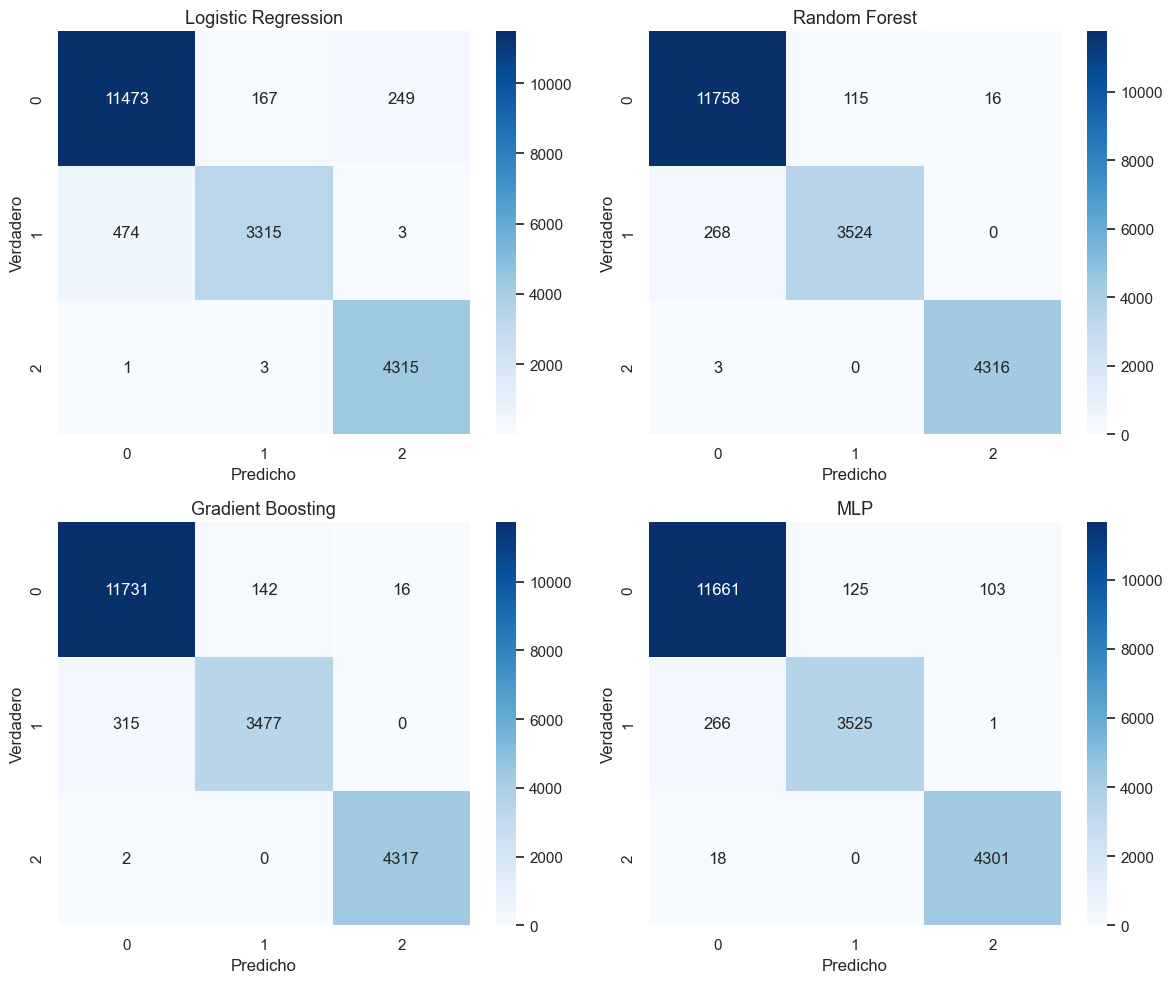

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
labels = np.unique(y_test)

for ax, (name, pipe) in zip(axes, fitted.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_ylabel("Verdadero")
    ax.set_xlabel("Predicho")

plt.tight_layout()
plt.show()



**Interpretación:** compare bloques fuera de diagonal entre modelos. Si QSO se confunde sistemáticamente con GALAXY o STAR, suele hablarse de solapamiento fotométrico o de objetos con propiedades intermedias; la matriz cuantifica ese patrón.


## 10. Optimización con `GridSearchCV`

Ajustamos hiperparámetros del **mismo pipeline** (preprocesamiento + clasificador) mediante búsqueda en rejilla. Usamos validación cruzada **estratificada** y optimizamos **`f1_macro`** para no ignorar clases minoritarias.

Por coste computacional, la rejilla se aplica al **Random Forest** (buen compromiso calidad/tiempo en tabular). Puedes duplicar el patrón para otros estimadores.


In [70]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "clf__n_estimators": [100, 250],
    "clf__max_depth": [12, 20, None],
    "clf__min_samples_leaf": [1, 2],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_rf = GridSearchCV(
    estimator=make_model_pipeline(
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample",
        )
    ),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

grid_rf.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_rf.best_params_)
print("Mejor F1 macro (CV):", round(grid_rf.best_score_, 4))



Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 250}
Mejor F1 macro (CV): 0.9746


In [71]:
y_pred_tuned = grid_rf.predict(X_test)
print(classification_report(y_test, y_pred_tuned))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_tuned), 4))

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_tuned, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.title("Matriz de confusión — Random Forest (GridSearchCV)")
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()



              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11889
           1       0.97      0.93      0.95      3792
           2       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000

Accuracy test: 0.9799


AttributeError: 'numpy.ndarray' object has no attribute 'unique'

## 11. Interpretabilidad: importancia de variables

### 11.1 Importancia basada en árboles

`RandomForestClassifier.feature_importances_` resume la **reducción promedio de impureza** atribuible a cada variable. Con *features* correlacionadas (típico en magnitudes), varias variables pueden **repartirse** la importancia: no siempre implica causalidad astrofísica directa.

### 11.2 *Permutation importance* (más fiel al modelo ya entrenado)

Permuta una columna en el conjunto de prueba y mide el **daño** en el score: si empeora mucho, la variable era clave para ese modelo.


In [ ]:
from sklearn.inspection import permutation_importance

best_rf = grid_rf.best_estimator_
feat_names = best_rf.named_steps["prep"].get_feature_names_out()
imp = best_rf.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": imp}).sort_values("importance", ascending=False)
imp_df



In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=imp_df, x="importance", y="feature", palette="crest")
plt.title("Importancia Gini (Random Forest optimizado)")
plt.tight_layout()
plt.show()



In [ ]:
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame(
        {
            "feature": feat_names,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
perm_df



## 12. Discusión científica

**Coherencia con la astrofísica:** las magnitudes SDSS codifican forma del espectro energético aproximado; los **colores** (diferencias entre bandas) separan en parte estrellas, galaxias y AGN/cuásares. Si `redshift` domina la importancia, es esperable: en este dataset es una variable **espectroscópicamente informada** y las tres clases ocupan rangos de redshift distintos en la práctica (las galaxias cercanas vs cuásares de alto z, etc.).

**Qué implica para la ciencia de datos:** un modelo con `redshift` puede ser excelente para **replicar la clasificación espectroscópica** cuando ya mediste redshift; no sustituye el problema de **fotometría pura** en el cielo amplio. Para un segundo experimento de portafolio, repite el flujo eliminando `redshift` de `FEATURE_COLS` y compara F1 y matrices de confusión.

**Erresistemáticos:** confusiones STAR–GALAXY en límite de resolución/PSF o QSO–STAR por puntos brillantes pueden reflejarse en la matriz; enlazar esos bloques con la literatura SDSS fortalece la narrativa del proyecto.


## 13. Conclusiones

- **Mejor enfoque en este notebook:** comparamos cuatro *baselines* en pipeline y luego un **Random Forest** optimizado con `GridSearchCV`. El modelo final y sus métricas deben leerse de `metrics_df` y del `classification_report` del RF afinado.

- **Limitaciones:** datos tabulares estáticos; posible **sesgo de selección** del survey; `redshift` hace el problema más fácil; no modelamos incertidumbres fotométricas explícitas ni propiedades morfológicas extendidas.

- **Mejoras futuras:** experimento sin `redshift`; **calibración probabilística** (Platt / isotónica); **`HistGradientBoostingClassifier`** o **XGBoost/LightGBM** con la misma API de pipeline; validación temporal o por *plate/run* para detectar **deriva de datos**; empaquetado del pipeline con **ONNX** o **skops** para despliegue.

---

*Notebook listo para portafolio: flujo reproducible, métricas multiclase, optimización e interpretación alineadas con el contexto SDSS.*
